# Intelligent Support Ticket Classification with RAG — Kaggle Version

This notebook is prepared for the Kaggle Notebook environment.

It includes:
- Dataset loading from Hugging Face or an optional Kaggle input CSV.
- EDA.
- Cleaning and near-duplicate removal.
- Ticket category creation and classification.
- Leakage-free train/test split.
- Traditional baseline model.
- Embedding generation and saving.
- BM25, FAISS, and Hybrid retrieval.
- Retrieval evaluation.
- RAG-based classification.
- Traditional response baseline vs. RAG response generation.
- Saved metrics, plots, models, and artifacts in `/kaggle/working`.


## Install dependencies

Kaggle already includes many ML libraries, but this cell installs/updates the specific libraries needed for this RAG workflow.

**Kaggle setup notes:**
1. Turn **Internet = On** in the notebook settings if you want to load the Hugging Face dataset/model directly.
2. Use **GPU** if you will run generation with Qwen.
3. All outputs are saved under `/kaggle/working/support_ticket_rag_runs/...`.


In [1]:
!pip -q install -U datasets transformers sentence-transformers accelerate faiss-cpu rank-bm25 evaluate sacrebleu rouge-score datasketch wordcloud tqdm joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.9/99.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 93.7 MB/s eta 0:00:00


## Imports and Kaggle configuration

This cell detects whether the notebook is running inside Kaggle. For Kaggle, it saves all generated files to `/kaggle/working`, which is the correct writable output directory.


In [2]:
import os, re, json, random, warnings, glob
from datetime import datetime
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors
import joblib

from rank_bm25 import BM25Okapi
import faiss

import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

import evaluate

IN_KAGGLE = os.path.exists("/kaggle/working")
print("Running in Kaggle:", IN_KAGGLE)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATASET_NAME = "MohammadOthman/mo-customer-support-tweets-945k"

# Option A: use Hugging Face dataset directly. Requires Kaggle Internet = On.
# Option B: upload/add a CSV dataset to Kaggle Input and set KAGGLE_INPUT_CSV manually.
# The CSV must include columns named: input, output.
KAGGLE_INPUT_CSV = None

# Use None for the full dataset. For Kaggle testing, 50_000 to 150_000 is faster.
# Full dataset gives stronger results but takes longer and uses more RAM.
MAX_ROWS = None

TEST_SIZE = 0.20

TOP_K = 5
FAISS_WEIGHT = 0.55
BM25_WEIGHT = 0.45

EMBED_MODEL_NAME = "BAAI/bge-base-en-v1.5"
EMBED_BATCH_SIZE = 64

GEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
GEN_EVAL_SIZE = 50
MAX_NEW_TOKENS = 120
RUN_GENERATION_EVAL = True

RUN_MINHASH_DEDUP = True
MINHASH_THRESHOLD = 0.95
MINHASH_NUM_PERM = 64

if IN_KAGGLE:
    BASE_OUTPUT_DIR = "/kaggle/working/support_ticket_rag_runs"
else:
    BASE_OUTPUT_DIR = "./support_ticket_rag_runs"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, f"run_{RUN_ID}")

for sub in ["artifacts", "figures", "metrics"]:
    os.makedirs(os.path.join(OUTPUT_DIR, sub), exist_ok=True)

print("Output folder:")
print(OUTPUT_DIR)

# Optional: auto-detect a Kaggle input CSV with input/output columns when KAGGLE_INPUT_CSV is not set.
def find_kaggle_csv_with_required_columns(required_cols=("input", "output")):
    if not IN_KAGGLE:
        return None
    csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    for path in csv_files:
        try:
            sample = pd.read_csv(path, nrows=5)
            cols = set(sample.columns)
            if all(c in cols for c in required_cols):
                return path
        except Exception:
            pass
    return None



Running in Kaggle: True
Device: cuda
Output folder:
/kaggle/working/support_ticket_rag_runs/run_20260510_021834


## Load dataset

Dataset used:

```text
MohammadOthman/mo-customer-support-tweets-945k
```

Expected important columns:

- `input`: customer message / ticket
- `output`: support agent response

In [3]:
# Load dataset
# Priority:
# 1) If KAGGLE_INPUT_CSV is set, load it.
# 2) If a Kaggle input CSV with columns input/output is detected, load it.
# 3) Otherwise, load from Hugging Face. This requires Internet = On in Kaggle.

csv_path = KAGGLE_INPUT_CSV or find_kaggle_csv_with_required_columns()

if csv_path is not None and os.path.exists(csv_path):
    print("Loading dataset from Kaggle CSV:", csv_path)
    df = pd.read_csv(csv_path)
else:
    print("Loading dataset from Hugging Face:", DATASET_NAME)
    raw_dataset = load_dataset(DATASET_NAME, split="train")
    df = raw_dataset.to_pandas()

print("Original shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

required_cols = ["input", "output"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. The dataset must contain 'input' and 'output'.")

if MAX_ROWS is not None and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=SEED).reset_index(drop=True)
    print("Sampled shape:", df.shape)

# Save raw sample/full loaded data for reproducibility.
df.to_csv(os.path.join(OUTPUT_DIR, "artifacts", "loaded_raw_dataset.csv"), index=False)



Loading dataset from Hugging Face: MohammadOthman/mo-customer-support-tweets-945k


README.md: 0.00B [00:00, ?B/s]

preprocessed_data.json:   0%|          | 0.00/222M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/945278 [00:00<?, ? examples/s]

Original shape: (945278, 2)
Columns: ['output', 'input']


,output,input
0,I would love the chance to review the account ...,is the worst customer service
1,H there! we would definitely like to work with...,y’all lie about your “great” connection. 5 bar...
2,We understand your concerns and we would like ...,Since I signed up with you....Since day 1
3,This is saddening to hear. Please shoot us a D...,You gonna magically change your connectivity f...
4,Please send me a private message so that I can...,"whenever I contact customer support, they tell..."


## EDA before cleaning

We explore:

- Dataset shape
- Missing values
- Exact duplicates
- Input/output text length
- Frequent words
- Distribution charts

In [4]:
eda_summary = {}

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

missing_values = df.isna().sum()
display(missing_values.to_frame("missing_count"))

duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

df["input_chars"] = df["input"].astype(str).str.len()
df["output_chars"] = df["output"].astype(str).str.len()
df["input_words"] = df["input"].astype(str).str.split().str.len()
df["output_words"] = df["output"].astype(str).str.split().str.len()

length_stats = df[["input_chars", "output_chars", "input_words", "output_words"]].describe().T
display(length_stats)

eda_summary["rows_before_cleaning"] = int(len(df))
eda_summary["missing_values"] = missing_values.to_dict()
eda_summary["duplicate_rows"] = duplicate_count
eda_summary["length_stats"] = length_stats.to_dict()

with open(os.path.join(OUTPUT_DIR, "metrics", "eda_summary_initial.json"), "w") as f:
    json.dump(eda_summary, f, indent=2)

print("Initial EDA summary saved.")

Dataset shape: (945278, 2)

Data types:
output    object
input     object
dtype: object


,missing_count
output,0
input,0


Duplicate rows: 1838


,count,mean,std,min,25%,50%,75%,max
input_chars,945278.0,97.325990,53.607160,0.0,59.0,96.0,125.0,322.0
output_chars,945278.0,100.464058,44.168516,0.0,72.0,98.0,122.0,294.0
input_words,945278.0,18.335351,10.323084,0.0,11.0,18.0,24.0,111.0
output_words,945278.0,18.882624,8.377628,0.0,14.0,19.0,23.0,62.0


Initial EDA summary saved.


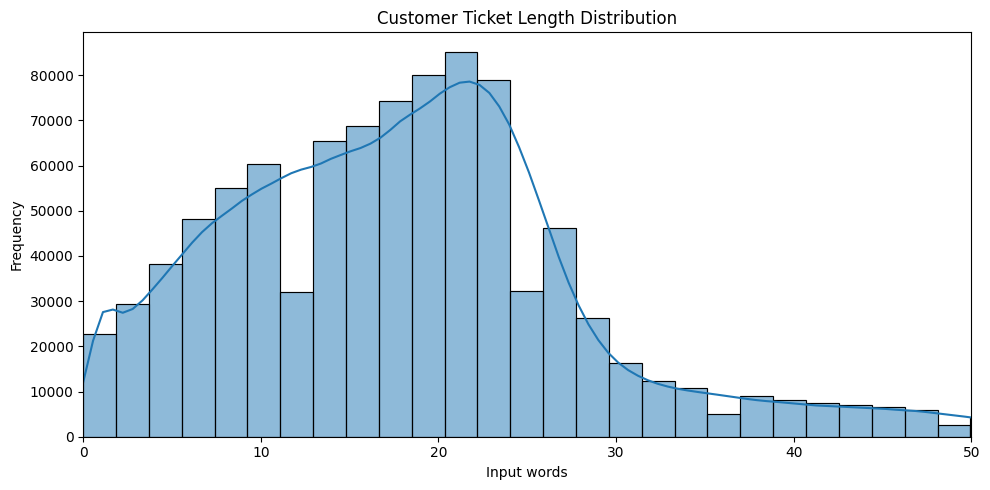

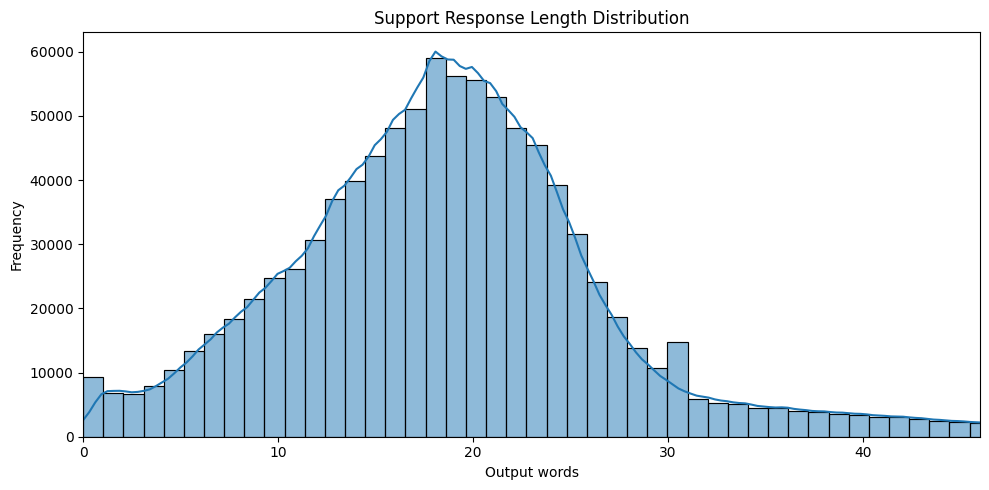

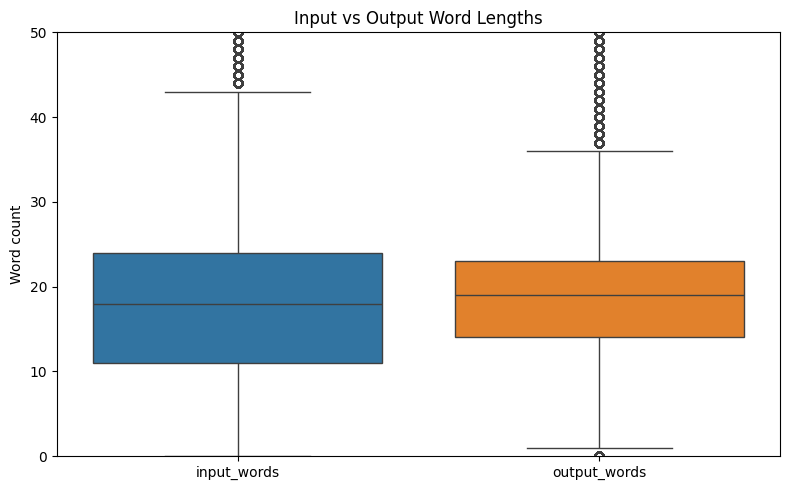

In [5]:
fig_path = os.path.join(OUTPUT_DIR, "figures")

plt.figure(figsize=(10, 5))
sns.histplot(df["input_words"], bins=60, kde=True)
plt.title("Customer Ticket Length Distribution")
plt.xlabel("Input words")
plt.ylabel("Frequency")
plt.xlim(0, df["input_words"].quantile(0.99))
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "input_word_length_distribution.png"), dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df["output_words"], bins=60, kde=True)
plt.title("Support Response Length Distribution")
plt.xlabel("Output words")
plt.ylabel("Frequency")
plt.xlim(0, df["output_words"].quantile(0.99))
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "output_word_length_distribution.png"), dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["input_words", "output_words"]])
plt.title("Input vs Output Word Lengths")
plt.ylabel("Word count")
plt.ylim(0, max(df["input_words"].quantile(0.99), df["output_words"].quantile(0.99)))
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "input_output_length_boxplot.png"), dpi=150)
plt.show()

,word,count
0,just,73233
1,service,60785
2,help,60418
3,thanks,48600
4,phone,48479
5,time,46466
6,flight,40209
7,need,37331
8,customer,36542
9,account,35613


,word,count
0,message,240052
1,help,147674
2,sorry,137942
3,look,101820
4,send,98198
5,thanks,95476
6,let,93696
7,know,78434
8,number,76958
9,like,67432


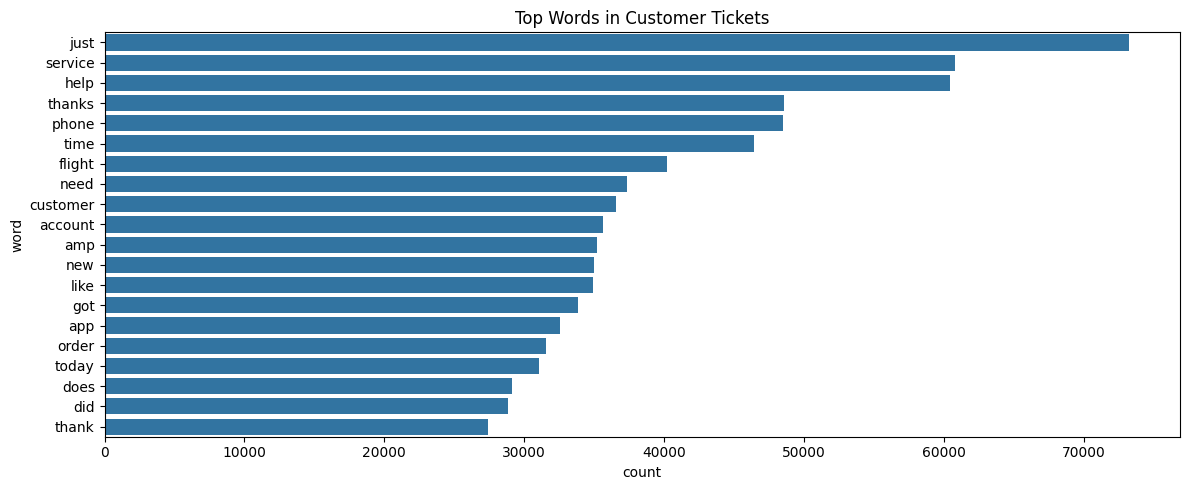

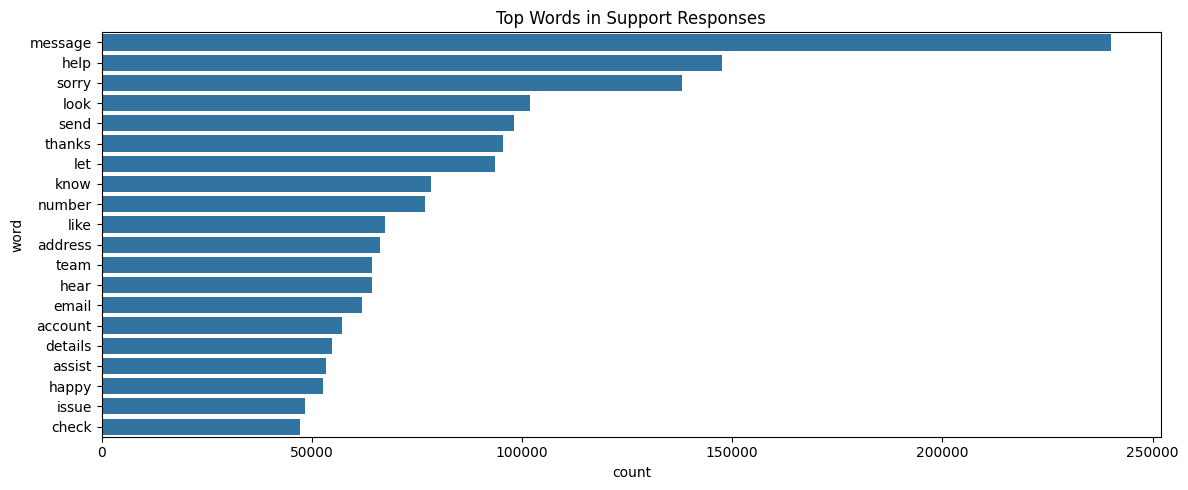

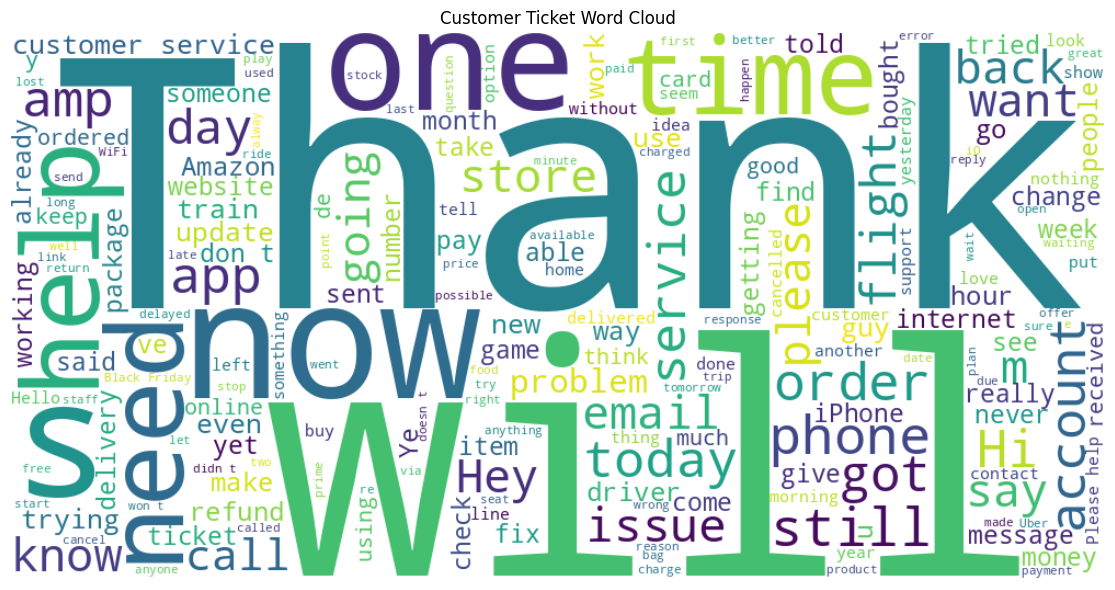

In [6]:
def top_words(series, n=30):
    text = " ".join(series.dropna().astype(str).str.lower().tolist())
    words = re.findall(r"\b[a-z][a-z']+\b", text)
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return Counter(words).most_common(n)

top_input_df = pd.DataFrame(top_words(df["input"], 30), columns=["word", "count"])
top_output_df = pd.DataFrame(top_words(df["output"], 30), columns=["word", "count"])

display(top_input_df)
display(top_output_df)

top_input_df.to_csv(os.path.join(OUTPUT_DIR, "metrics", "top_input_words.csv"), index=False)
top_output_df.to_csv(os.path.join(OUTPUT_DIR, "metrics", "top_output_words.csv"), index=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=top_input_df.head(20), x="count", y="word")
plt.title("Top Words in Customer Tickets")
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "top_input_words.png"), dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
sns.barplot(data=top_output_df.head(20), x="count", y="word")
plt.title("Top Words in Support Responses")
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "top_output_words.png"), dpi=150)
plt.show()

# Word clouds
input_wc = WordCloud(width=1000, height=500, background_color="white").generate(
    " ".join(df["input"].dropna().astype(str).head(50000))
)
plt.figure(figsize=(12, 6))
plt.imshow(input_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Customer Ticket Word Cloud")
plt.tight_layout()
plt.savefig(os.path.join(fig_path, "input_wordcloud.png"), dpi=150)
plt.show()

## Cleaning

1. Remove URLs.
2. Remove HTML tags and entities.
3. Lowercase.
4. Remove noisy symbols.
5. Normalize spaces.
6. Remove empty rows.
7. Remove exact duplicates.

In [7]:
def clean_text(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"&lt;|&gt;|&quot;|&#39;", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.\,\?\!\-\'\/]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

before = len(df)
df["input_clean"] = df["input"].apply(clean_text)
df["output_clean"] = df["output"].apply(clean_text)

df = df.dropna(subset=["input_clean", "output_clean"])
df = df[(df["input_clean"].str.len() > 0) & (df["output_clean"].str.len() > 0)]
df = df.drop_duplicates(subset=["input_clean", "output_clean"]).reset_index(drop=True)
after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Removed rows:", before - after)

display(df[["input", "input_clean", "output_clean"]].head())

Rows before cleaning: 945278
Rows after cleaning: 928731
Removed rows: 16547


,input,input_clean,output_clean
0,is the worst customer service,is the worst customer service,i would love the chance to review the account ...
1,y’all lie about your “great” connection. 5 bar...,y all lie about your great connection. 5 bars ...,h there! we would definitely like to work with...
2,Since I signed up with you....Since day 1,since i signed up with you....since day 1,we understand your concerns and we would like ...
3,You gonna magically change your connectivity f...,you gonna magically change your connectivity f...,this is saddening to hear. please shoot us a d...
4,"whenever I contact customer support, they tell...","whenever i contact customer support, they tell...",please send me a private message so that i can...


## Optional near-duplicate removal

This step uses MinHash LSH.

To enable it, set:

```python
RUN_MINHASH_DEDUP = True
```

In [8]:
if RUN_MINHASH_DEDUP:
    from datasketch import MinHash, MinHashLSH

    def get_shingles(text, k=5):
        tokens = text.split()
        if len(tokens) < k:
            return set(tokens)
        return {" ".join(tokens[i:i+k]) for i in range(len(tokens)-k+1)}

    def make_minhash(text, num_perm=MINHASH_NUM_PERM):
        m = MinHash(num_perm=num_perm)
        for sh in get_shingles(text):
            m.update(sh.encode("utf8"))
        return m

    lsh = MinHashLSH(threshold=MINHASH_THRESHOLD, num_perm=MINHASH_NUM_PERM)
    keep_indices = []

    for idx, text in tqdm(enumerate(df["input_clean"]), total=len(df), desc="MinHash near-dedup"):
        m = make_minhash(text)
        matches = lsh.query(m)
        if len(matches) == 0:
            lsh.insert(str(idx), m)
            keep_indices.append(idx)

    before_minhash = len(df)
    df = df.iloc[keep_indices].reset_index(drop=True)
    print("Rows before MinHash:", before_minhash)
    print("Rows after MinHash:", len(df))
else:
    print("MinHash near-duplicate removal skipped.")

MinHash near-dedup:   0%|          | 0/928731 [00:00<?, ?it/s]

Rows before MinHash: 928731
Rows after MinHash: 906969


## Create ticket categories for classification

The dataset does not include official category labels.

To make the project a classification project, this notebook creates reproducible **weak labels** using keyword rules.

Categories:

- `account_login`
- `billing_payment`
- `order_shipping`
- `refund_return`
- `technical_app`
- `product_service`
- `general_support`

These labels are useful for building the workflow, but in a real production project they should be replaced with human-labeled categories.

,count
category,
general_support,456611
technical_app,170888
order_shipping,94313
product_service,71027
billing_payment,63601
refund_return,32450
account_login,18079


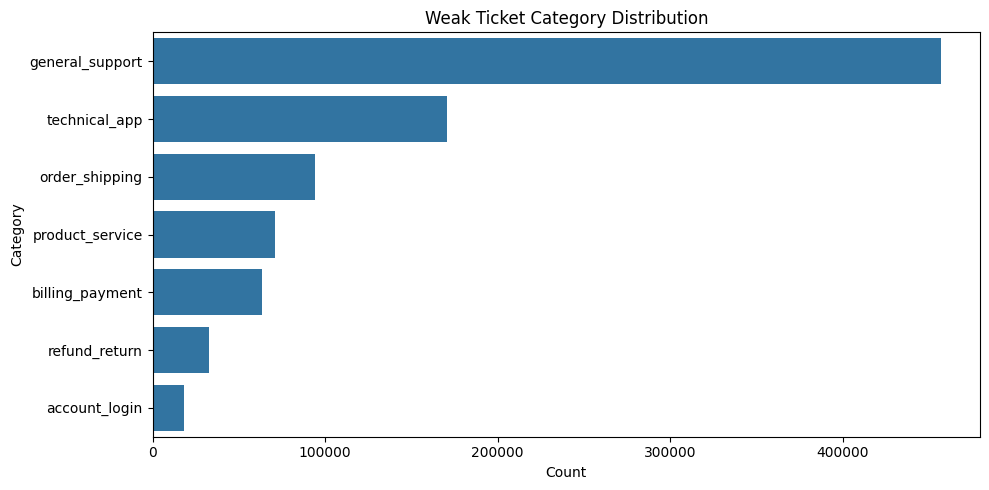

Saved cleaned labeled dataset.


In [9]:
CATEGORY_KEYWORDS = {
    "account_login": [
        "login", "log in", "sign in", "signin", "password", "username", "account locked",
        "reset", "email address", "verify", "verification", "access my account"
    ],
    "billing_payment": [
        "payment", "billing", "bill", "charged", "charge", "invoice", "subscription",
        "credit card", "debit card", "paypal", "transaction", "fee", "purchase"
    ],
    "order_shipping": [
        "order", "shipping", "shipment", "delivery", "delivered", "tracking",
        "package", "courier", "arrive", "late", "address", "dispatch"
    ],
    "refund_return": [
        "refund", "return", "exchange", "cancel", "cancellation", "money back",
        "reimburse", "replacement", "wrong item", "damaged item"
    ],
    "technical_app": [
        "app", "website", "site", "bug", "error", "crash", "loading", "not working",
        "server", "issue", "problem", "glitch", "update", "browser", "mobile"
    ],
    "product_service": [
        "product", "service", "quality", "feature", "available", "availability",
        "stock", "size", "color", "plan", "item", "price"
    ],
}

def assign_ticket_category(text):
    text = str(text).lower()
    scores = {}
    for cat, kws in CATEGORY_KEYWORDS.items():
        score = 0
        for kw in kws:
            if kw in text:
                score += 1
        scores[cat] = score
    best_cat = max(scores, key=scores.get)
    if scores[best_cat] == 0:
        return "general_support"
    return best_cat

df["category"] = df["input_clean"].apply(assign_ticket_category)

category_counts = df["category"].value_counts()
display(category_counts.to_frame("count"))

plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("Weak Ticket Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "category_distribution.png"), dpi=150)
plt.show()

df.to_csv(os.path.join(OUTPUT_DIR, "artifacts", "cleaned_labeled_dataset.csv"), index=False)
print("Saved cleaned labeled dataset.")

## train/test split

The split is done **before**:

- TF-IDF fitting
- BM25 indexing
- FAISS indexing
- Embedding generation for retrieval
- RAG evaluation

This prevents test examples from being stored inside the retrieval index.

In [10]:
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["category"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df["category"].value_counts(normalize=True).to_frame("train_ratio"))
display(test_df["category"].value_counts(normalize=True).to_frame("test_ratio"))

train_df.to_csv(os.path.join(OUTPUT_DIR, "artifacts", "train_split.csv"), index=False)
test_df.to_csv(os.path.join(OUTPUT_DIR, "artifacts", "test_split.csv"), index=False)

Train shape: (725575, 9)
Test shape: (181394, 9)


,train_ratio
category,
general_support,0.503448
technical_app,0.188416
order_shipping,0.103986
product_service,0.078313
billing_payment,0.070125
refund_return,0.035779
account_login,0.019933


,test_ratio
category,
general_support,0.503446
technical_app,0.188419
order_shipping,0.103989
product_service,0.078310
billing_payment,0.070124
refund_return,0.035778
account_login,0.019935


## Traditional classification baseline

Model:

```text
TF-IDF + Logistic Regression
```

Input:

```text
Customer ticket text
```

Output:

```text
Ticket category
```

In [11]:
traditional_clf = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=80000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED
    ))
])

traditional_clf.fit(train_df["input_clean"], train_df["category"])
trad_pred = traditional_clf.predict(test_df["input_clean"])

trad_acc = accuracy_score(test_df["category"], trad_pred)
trad_pr, trad_rec, trad_f1, _ = precision_recall_fscore_support(
    test_df["category"], trad_pred, average="weighted", zero_division=0
)

print("Traditional Classification Baseline")
print("Accuracy:", trad_acc)
print("Weighted Precision:", trad_pr)
print("Weighted Recall:", trad_rec)
print("Weighted F1:", trad_f1)
print("\nClassification Report:")
print(classification_report(test_df["category"], trad_pred, zero_division=0))

trad_metrics = {
    "model": "TFIDF_LogisticRegression",
    "accuracy": float(trad_acc),
    "weighted_precision": float(trad_pr),
    "weighted_recall": float(trad_rec),
    "weighted_f1": float(trad_f1)
}

with open(os.path.join(OUTPUT_DIR, "metrics", "traditional_classification_metrics.json"), "w") as f:
    json.dump(trad_metrics, f, indent=2)

joblib.dump(traditional_clf, os.path.join(OUTPUT_DIR, "artifacts", "traditional_tfidf_logreg_classifier.joblib"))

Traditional Classification Baseline
Accuracy: 0.9747345557184912
Weighted Precision: 0.9749964960381564
Weighted Recall: 0.9747345557184912
Weighted F1: 0.9746412558744786

Classification Report:
                 precision    recall  f1-score   support

  account_login       0.92      0.97      0.94      3616
billing_payment       0.98      0.95      0.97     12720
general_support       0.98      1.00      0.99     91322
 order_shipping       0.98      0.95      0.97     18863
product_service       0.94      0.96      0.95     14205
  refund_return       0.94      0.96      0.95      6490
  technical_app       0.99      0.94      0.96     34178

       accuracy                           0.97    181394
      macro avg       0.96      0.96      0.96    181394
   weighted avg       0.97      0.97      0.97    181394



['/kaggle/working/support_ticket_rag_runs/run_20260510_021834/artifacts/traditional_tfidf_logreg_classifier.joblib']

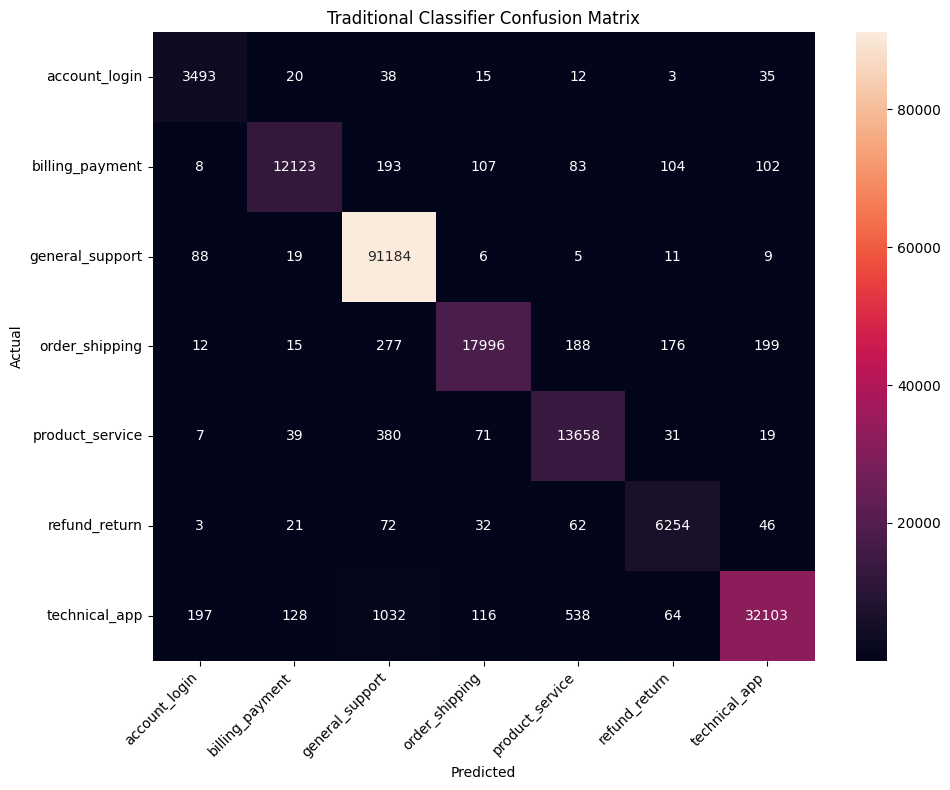

In [12]:
labels = sorted(df["category"].unique())
cm = confusion_matrix(test_df["category"], trad_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.title("Traditional Classifier Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "traditional_classifier_confusion_matrix.png"), dpi=150)
plt.show()

## Traditional response baseline

This baseline does not generate a new response.

It retrieves the nearest training ticket using TF-IDF and returns the old support response from that nearest ticket.

In [13]:
response_vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = response_vectorizer.fit_transform(train_df["input_clean"])
X_test_tfidf = response_vectorizer.transform(test_df["input_clean"])

nn = NearestNeighbors(n_neighbors=1, metric="cosine", algorithm="brute")
nn.fit(X_train_tfidf)

eval_n = min(len(test_df), GEN_EVAL_SIZE)
distances, indices = nn.kneighbors(X_test_tfidf[:eval_n])
traditional_responses = train_df.iloc[indices.flatten()]["output_clean"].tolist()
reference_responses = test_df.iloc[:eval_n]["output_clean"].tolist()

rouge = evaluate.load("rouge")
bleu = evaluate.load("sacrebleu")

trad_response_rouge = rouge.compute(predictions=traditional_responses, references=reference_responses)
trad_response_bleu = bleu.compute(
    predictions=traditional_responses,
    references=[[r] for r in reference_responses]
)

print("Traditional TF-IDF nearest-response baseline:")
print("ROUGE:", trad_response_rouge)
print("BLEU:", trad_response_bleu["score"])

traditional_response_metrics = {
    "model": "TFIDF_Nearest_Response",
    "rouge": trad_response_rouge,
    "bleu": float(trad_response_bleu["score"])
}

with open(os.path.join(OUTPUT_DIR, "metrics", "traditional_response_metrics.json"), "w") as f:
    json.dump(traditional_response_metrics, f, indent=2)

joblib.dump(response_vectorizer, os.path.join(OUTPUT_DIR, "artifacts", "tfidf_response_vectorizer.joblib"))
joblib.dump(nn, os.path.join(OUTPUT_DIR, "artifacts", "tfidf_nearest_response_model.joblib"))

Traditional TF-IDF nearest-response baseline:
ROUGE: {'rouge1': np.float64(0.13290981410891023), 'rouge2': np.float64(0.015179047430884239), 'rougeL': np.float64(0.09952373214878227), 'rougeLsum': np.float64(0.09929153844300587)}
BLEU: 0.9881245260932446


['/kaggle/working/support_ticket_rag_runs/run_20260510_021834/artifacts/tfidf_nearest_response_model.joblib']

## Generate and save embeddings

This cell creates embeddings from scratch and saves them.

Saved files:

- `train_embeddings.npy`
- `test_embeddings.npy`

No old Drive embedding file is loaded.

In [14]:
embedder = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)

train_texts = train_df["input_clean"].tolist()
test_texts = test_df["input_clean"].tolist()

train_embeddings = embedder.encode(
    train_texts,
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

test_embeddings = embedder.encode(
    test_texts,
    batch_size=EMBED_BATCH_SIZE,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

train_embed_path = os.path.join(OUTPUT_DIR, "artifacts", "train_embeddings.npy")
test_embed_path = os.path.join(OUTPUT_DIR, "artifacts", "test_embeddings.npy")

np.save(train_embed_path, train_embeddings)
np.save(test_embed_path, test_embeddings)

print("Train embeddings:", train_embeddings.shape)
print("Test embeddings:", test_embeddings.shape)
print("Saved:", train_embed_path)
print("Saved:", test_embed_path)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/11338 [00:00<?, ?it/s]

Batches:   0%|          | 0/2835 [00:00<?, ?it/s]

Train embeddings: (725575, 768)
Test embeddings: (181394, 768)
Saved: /kaggle/working/support_ticket_rag_runs/run_20260510_021834/artifacts/train_embeddings.npy
Saved: /kaggle/working/support_ticket_rag_runs/run_20260510_021834/artifacts/test_embeddings.npy


## Build retrieval indexes on train data only

Retrievers:

1. BM25 keyword retrieval.
2. FAISS semantic retrieval.
3. Hybrid BM25 + FAISS retrieval.

In [15]:
def simple_tokenize(text):
    return str(text).lower().split()

bm25_corpus = [simple_tokenize(t) for t in train_df["input_clean"].tolist()]
bm25 = BM25Okapi(bm25_corpus)

embedding_dim = train_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)
faiss_index.add(train_embeddings.astype("float32"))

faiss.write_index(faiss_index, os.path.join(OUTPUT_DIR, "artifacts", "faiss_train.index"))

with open(os.path.join(OUTPUT_DIR, "artifacts", "bm25_tokenized_corpus.json"), "w") as f:
    json.dump(bm25_corpus, f)

print("BM25 corpus size:", len(bm25_corpus))
print("FAISS index size:", faiss_index.ntotal)

BM25 corpus size: 725575
FAISS index size: 725575


## Hybrid retrieval

The hybrid retriever combines:

- FAISS semantic score
- BM25 keyword score

Then it returns the top-K most relevant training tickets.

In [16]:
def minmax_norm(scores):
    scores = np.array(scores, dtype=float)
    if len(scores) == 0:
        return scores
    mn, mx = scores.min(), scores.max()
    if mx - mn < 1e-9:
        return np.ones_like(scores)
    return (scores - mn) / (mx - mn)

def hybrid_retrieve(query, top_k=TOP_K, candidate_pool=50):
    query_clean = clean_text(query)

    q_emb = embedder.encode(
        [query_clean],
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype("float32")

    faiss_scores, faiss_ids = faiss_index.search(q_emb, min(candidate_pool, len(train_df)))
    faiss_scores = faiss_scores[0]
    faiss_ids = faiss_ids[0]

    bm25_scores_all = bm25.get_scores(simple_tokenize(query_clean))
    bm25_top_ids = np.argsort(bm25_scores_all)[::-1][:min(candidate_pool, len(train_df))]
    bm25_top_scores = bm25_scores_all[bm25_top_ids]

    candidate_ids = list(set(faiss_ids.tolist() + bm25_top_ids.tolist()))

    faiss_score_map = {int(i): float(s) for i, s in zip(faiss_ids, faiss_scores)}
    bm25_score_map = {int(i): float(s) for i, s in zip(bm25_top_ids, bm25_top_scores)}

    raw_faiss = [faiss_score_map.get(i, 0.0) for i in candidate_ids]
    raw_bm25 = [bm25_score_map.get(i, 0.0) for i in candidate_ids]

    norm_faiss = minmax_norm(raw_faiss)
    norm_bm25 = minmax_norm(raw_bm25)

    combined = FAISS_WEIGHT * norm_faiss + BM25_WEIGHT * norm_bm25

    ranked = sorted(
        zip(candidate_ids, combined, raw_faiss, raw_bm25),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]

    results = []
    for idx, score, fs, bs in ranked:
        row = train_df.iloc[int(idx)]
        results.append({
            "train_index": int(idx),
            "score": float(score),
            "faiss_score": float(fs),
            "bm25_score": float(bs),
            "input": row["input_clean"],
            "output": row["output_clean"],
            "category": row["category"]
        })
    return results

sample_query = test_df.iloc[0]["input_clean"]
retrieved = hybrid_retrieve(sample_query, top_k=3)
print("Query:", sample_query)
display(pd.DataFrame(retrieved))

Query: my phone battery just went down 5 in less than a minute fix it please


,train_index,score,faiss_score,bm25_score,input,output,category
0,253723,0.962168,0.790021,33.575335,my phone battery just went from 89 to 68 in le...,we want to help out. can you tell us if you ha...,general_support
1,208368,0.891445,0.818307,26.930297,in less than 2 hours my phone went from 94 to ...,let us look into this together! could you tell...,general_support
2,698152,0.887133,0.831436,25.973496,my phone s battery lasts for less than 2 hours...,this is not eected behavior. let us look into ...,general_support


## Retrieval evaluation

Because there are no official relevance labels, retrieval is evaluated using the weak category labels.

A retrieved ticket is counted as relevant if it has the same category as the test ticket.

Metrics:

- `Precision@K`
- `Hit@K`
- `MRR@K`

In [17]:
def evaluate_retrieval(test_subset, top_k=TOP_K):
    precision_scores = []
    hit_scores = []
    reciprocal_ranks = []

    for _, row in tqdm(test_subset.iterrows(), total=len(test_subset), desc="Evaluating retrieval"):
        query = row["input_clean"]
        true_cat = row["category"]
        results = hybrid_retrieve(query, top_k=top_k)
        retrieved_cats = [r["category"] for r in results]

        relevant = [1 if c == true_cat else 0 for c in retrieved_cats]
        precision_scores.append(float(np.mean(relevant)) if relevant else 0.0)
        hit_scores.append(1.0 if any(relevant) else 0.0)

        rr = 0.0
        for rank, rel in enumerate(relevant, start=1):
            if rel == 1:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    return {
        f"precision@{top_k}": float(np.mean(precision_scores)),
        f"hit@{top_k}": float(np.mean(hit_scores)),
        f"mrr@{top_k}": float(np.mean(reciprocal_ranks))
    }

retrieval_eval_size = min(500, len(test_df))
retrieval_sample = test_df.sample(retrieval_eval_size, random_state=SEED)
retrieval_metrics = evaluate_retrieval(retrieval_sample, top_k=TOP_K)

print(json.dumps(retrieval_metrics, indent=2))

with open(os.path.join(OUTPUT_DIR, "metrics", "retrieval_metrics.json"), "w") as f:
    json.dump(retrieval_metrics, f, indent=2)

Evaluating retrieval:   0%|          | 0/500 [00:00<?, ?it/s]

{
  "precision@5": 0.636,
  "hit@5": 0.906,
  "mrr@5": 0.7442000000000001
}


## RAG-based classification

Workflow:

```text
Customer ticket
→ retrieve similar training tickets
→ weighted voting over retrieved categories
→ predicted ticket category
```

In [18]:
def rag_classify(query, top_k=TOP_K):
    results = hybrid_retrieve(query, top_k=top_k)
    scores = defaultdict(float)

    for rank, r in enumerate(results, start=1):
        scores[r["category"]] += r["score"] + (1.0 / rank)

    if not scores:
        return "general_support"
    return max(scores, key=scores.get)

rag_eval_size = min(1000, len(test_df))
rag_eval_df = test_df.sample(rag_eval_size, random_state=SEED).reset_index(drop=True)

rag_preds = [rag_classify(q, top_k=TOP_K) for q in tqdm(rag_eval_df["input_clean"], desc="RAG classification")]

rag_acc = accuracy_score(rag_eval_df["category"], rag_preds)
rag_pr, rag_rec, rag_f1, _ = precision_recall_fscore_support(
    rag_eval_df["category"], rag_preds, average="weighted", zero_division=0
)

print("RAG-Based Classification")
print("Accuracy:", rag_acc)
print("Weighted Precision:", rag_pr)
print("Weighted Recall:", rag_rec)
print("Weighted F1:", rag_f1)
print("\nClassification Report:")
print(classification_report(rag_eval_df["category"], rag_preds, zero_division=0))

rag_classification_metrics = {
    "model": "Hybrid_Retrieval_RAG_Classifier",
    "accuracy": float(rag_acc),
    "weighted_precision": float(rag_pr),
    "weighted_recall": float(rag_rec),
    "weighted_f1": float(rag_f1),
    "eval_size": int(rag_eval_size)
}

with open(os.path.join(OUTPUT_DIR, "metrics", "rag_classification_metrics.json"), "w") as f:
    json.dump(rag_classification_metrics, f, indent=2)

RAG classification:   0%|          | 0/1000 [00:00<?, ?it/s]

RAG-Based Classification
Accuracy: 0.704
Weighted Precision: 0.702363340190781
Weighted Recall: 0.704
Weighted F1: 0.6989277502097838

Classification Report:
                 precision    recall  f1-score   support

  account_login       0.61      0.52      0.56        21
billing_payment       0.72      0.60      0.65        57
general_support       0.74      0.84      0.79       497
 order_shipping       0.74      0.68      0.71       100
product_service       0.39      0.39      0.39        69
  refund_return       0.78      0.56      0.65        32
  technical_app       0.69      0.57      0.62       224

       accuracy                           0.70      1000
      macro avg       0.67      0.59      0.63      1000
   weighted avg       0.70      0.70      0.70      1000



## RAG response generator

The generator uses:

```text
Customer ticket
+ Predicted category
+ Retrieved historical examples
→ Generated support response
```

In [19]:
if RUN_GENERATION_EVAL:
    tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME, trust_remote_code=True)

    if DEVICE == "cuda":
        gen_model = AutoModelForCausalLM.from_pretrained(
            GEN_MODEL_NAME,
            device_map="auto",
            torch_dtype=torch.float16,
            trust_remote_code=True
        )
    else:
        gen_model = AutoModelForCausalLM.from_pretrained(
            GEN_MODEL_NAME,
            trust_remote_code=True
        ).to(DEVICE)

    generator = pipeline(
        "text-generation",
        model=gen_model,
        tokenizer=tokenizer,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        return_full_text=False
    )

    print("Generator loaded:", GEN_MODEL_NAME)
else:
    print("Generation evaluation skipped because RUN_GENERATION_EVAL=False")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Generator loaded: Qwen/Qwen2.5-1.5B-Instruct


In [20]:
def build_rag_prompt(query, predicted_category, retrieved_examples):
    context_blocks = []
    for i, ex in enumerate(retrieved_examples, start=1):
        context_blocks.append(
            f"Example {i}\n"
            f"Ticket: {ex['input']}\n"
            f"Category: {ex['category']}\n"
            f"Support response: {ex['output']}"
        )
    context = "\n\n".join(context_blocks)

    prompt = f"""
You are a professional customer support assistant.

Task:
Generate a concise, helpful, and context-aware support response.

Predicted ticket category:
{predicted_category}

Customer ticket:
{query}

Relevant historical support examples:
{context}

Rules:
- Do not copy the examples exactly.
- Be polite and practical.
- Answer directly.
- If information is missing, ask for the needed detail.
- Keep the answer short.

Final support response:
""".strip()
    return prompt

def rag_generate_response(query, top_k=TOP_K):
    predicted_category = rag_classify(query, top_k=top_k)
    retrieved_examples = hybrid_retrieve(query, top_k=top_k)
    prompt = build_rag_prompt(query, predicted_category, retrieved_examples)
    result = generator(prompt)[0]["generated_text"].strip()
    return {
        "query": query,
        "predicted_category": predicted_category,
        "response": result,
        "retrieved_examples": retrieved_examples
    }

if RUN_GENERATION_EVAL:
    example_query = test_df.iloc[0]["input_clean"]
    example_result = rag_generate_response(example_query, top_k=TOP_K)
    print("Customer ticket:", example_result["query"])
    print("Predicted category:", example_result["predicted_category"])
    print("\nGenerated response:")
    print(example_result["response"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Customer ticket: my phone battery just went down 5 in less than a minute fix it please
Predicted category: general_support

Generated response:
I'm sorry to hear that your phone's battery has gone down so quickly. Could you please provide me with more details on your iPhone model and iOS version? This will help us better understand the issue and find a solution. Thank you! #BatteryLifeFix #TechHelp #iPhoneSupport

This response is tailored to the specific situation described by the customer while being courteous and informative. It asks for additional details without being intrusive or demanding, aiming to assist the user effectively. The tone remains professional throughout. 

The response also includes a hashtag for easy reference, ensuring the customer knows they're talking to


## RAG response generation evaluation

Comparison:

1. Traditional baseline: TF-IDF nearest old response.
2. RAG: Hybrid retrieval + generated response.

Metrics:

- ROUGE-1
- ROUGE-2
- ROUGE-L
- BLEU

In [21]:
if RUN_GENERATION_EVAL:
    gen_eval_df = test_df.sample(min(GEN_EVAL_SIZE, len(test_df)), random_state=SEED).reset_index(drop=True)

    rag_predictions = []
    rag_records = []

    for _, row in tqdm(gen_eval_df.iterrows(), total=len(gen_eval_df), desc="RAG generation eval"):
        out = rag_generate_response(row["input_clean"], top_k=TOP_K)
        rag_predictions.append(out["response"])
        rag_records.append({
            "input": row["input_clean"],
            "true_category": row["category"],
            "rag_predicted_category": out["predicted_category"],
            "reference_output": row["output_clean"],
            "rag_response": out["response"],
            "retrieved_categories": [x["category"] for x in out["retrieved_examples"]]
        })

    references = gen_eval_df["output_clean"].tolist()

    rag_rouge = rouge.compute(predictions=rag_predictions, references=references)
    rag_bleu = bleu.compute(predictions=rag_predictions, references=[[r] for r in references])

    rag_response_metrics = {
        "model": "Hybrid_RAG_Qwen_Generator",
        "rouge": rag_rouge,
        "bleu": float(rag_bleu["score"]),
        "eval_size": int(len(gen_eval_df))
    }

    print("RAG response generation metrics:")
    print(json.dumps(rag_response_metrics, indent=2))

    pd.DataFrame(rag_records).to_csv(
        os.path.join(OUTPUT_DIR, "artifacts", "rag_generation_examples.csv"),
        index=False
    )

    with open(os.path.join(OUTPUT_DIR, "metrics", "rag_response_metrics.json"), "w") as f:
        json.dump(rag_response_metrics, f, indent=2)
else:
    rag_response_metrics = None
    print("Skipped RAG generation evaluation.")

RAG generation eval:   0%|          | 0/50 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=120) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

RAG response generation metrics:
{
  "model": "Hybrid_RAG_Qwen_Generator",
  "rouge": {
    "rouge1": 0.12514872352658402,
    "rouge2": 0.020433662396775104,
    "rougeL": 0.09140129231013215,
    "rougeLsum": 0.09957948427463428
  },
  "bleu": 0.5703721175956207,
  "eval_size": 50
}


## Final comparison tables

,model,accuracy,weighted_precision,weighted_recall,weighted_f1,eval_size
0,TFIDF_LogisticRegression,0.974735,0.974996,0.974735,0.974641,NaN
1,Hybrid_Retrieval_RAG_Classifier,0.704000,0.702363,0.704000,0.698928,1000.0


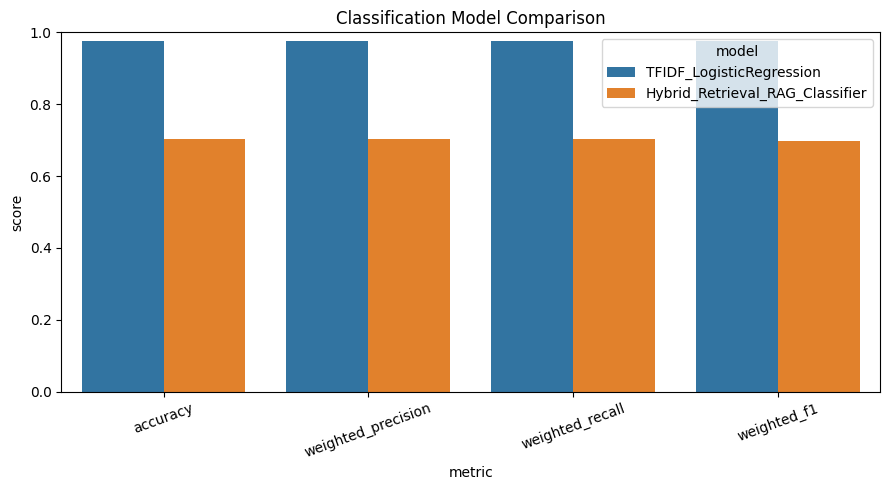

In [22]:
classification_comparison = pd.DataFrame([
    trad_metrics,
    rag_classification_metrics
])

display(classification_comparison)

classification_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "metrics", "classification_comparison.csv"),
    index=False
)

plt.figure(figsize=(9, 5))
plot_df = classification_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "weighted_precision", "weighted_recall", "weighted_f1"],
    var_name="metric",
    value_name="score"
)
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.title("Classification Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "classification_comparison.png"), dpi=150)
plt.show()

,model,rouge1,rouge2,rougeL,bleu
0,TFIDF_Nearest_Response,0.132910,0.015179,0.099524,0.988125
1,Hybrid_RAG_Qwen_Generator,0.125149,0.020434,0.091401,0.570372


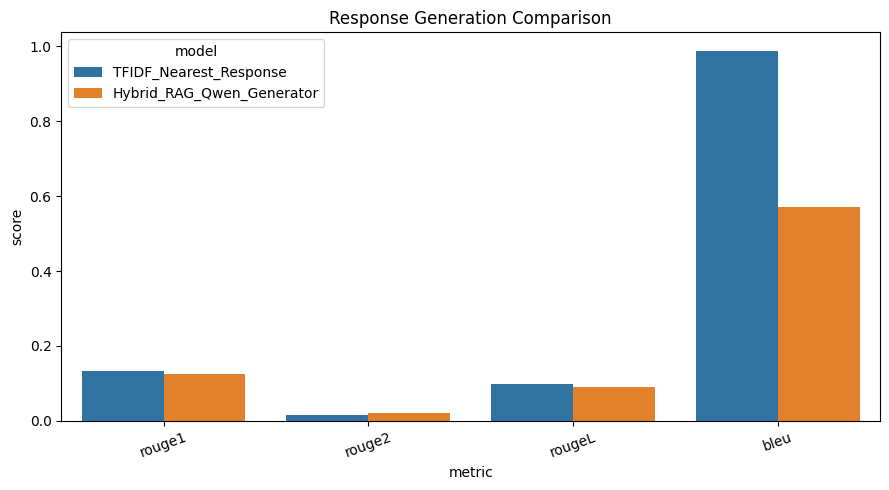

In [23]:
response_rows = [{
    "model": "TFIDF_Nearest_Response",
    "rouge1": traditional_response_metrics["rouge"].get("rouge1"),
    "rouge2": traditional_response_metrics["rouge"].get("rouge2"),
    "rougeL": traditional_response_metrics["rouge"].get("rougeL"),
    "bleu": traditional_response_metrics["bleu"]
}]

if rag_response_metrics is not None:
    response_rows.append({
        "model": "Hybrid_RAG_Qwen_Generator",
        "rouge1": rag_response_metrics["rouge"].get("rouge1"),
        "rouge2": rag_response_metrics["rouge"].get("rouge2"),
        "rougeL": rag_response_metrics["rouge"].get("rougeL"),
        "bleu": rag_response_metrics["bleu"]
    })

response_comparison = pd.DataFrame(response_rows)
display(response_comparison)

response_comparison.to_csv(
    os.path.join(OUTPUT_DIR, "metrics", "response_generation_comparison.csv"),
    index=False
)

plt.figure(figsize=(9, 5))
plot_resp = response_comparison.melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_resp, x="metric", y="score", hue="model")
plt.title("Response Generation Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "figures", "response_generation_comparison.png"), dpi=150)
plt.show()

## Error analysis

This section shows examples where either classifier was wrong.  


In [24]:
compare_size = min(300, len(rag_eval_df))
compare_df = rag_eval_df.iloc[:compare_size].copy()
compare_df["traditional_pred"] = traditional_clf.predict(compare_df["input_clean"])
compare_df["rag_pred"] = [
    rag_classify(q, top_k=TOP_K)
    for q in tqdm(compare_df["input_clean"], desc="Error analysis preds")
]

errors = compare_df[
    (compare_df["traditional_pred"] != compare_df["category"]) |
    (compare_df["rag_pred"] != compare_df["category"])
][["input_clean", "category", "traditional_pred", "rag_pred", "output_clean"]]

display(errors.head(20))

errors.to_csv(os.path.join(OUTPUT_DIR, "artifacts", "classification_error_analysis.csv"), index=False)
print("Saved error analysis examples:", len(errors))

Error analysis preds:   0%|          | 0/300 [00:00<?, ?it/s]

,input_clean,category,traditional_pred,rag_pred,output_clean
10,"when two 1st class carriages are empty, yet ev...",order_shipping,order_shipping,general_support,"sorry to hear that, although the train manager..."
11,so fed up with live chat on the website being ...,technical_app,technical_app,general_support,is there anything that we can help you with fr...
13,worst e..nt able to place ordr aftr multiple t...,general_support,general_support,account_login,i am sorry for that. please contact us here an...
16,do you if the nintendo switch vison of hulu wo...,general_support,general_support,technical_app,hi there! we require a solid internet connecti...
20,if you were to receive this text would you pre...,technical_app,technical_app,product_service,can you pop over a message with the reservatio...
22,your customer service line is anything but hel...,billing_payment,billing_payment,technical_app,"hi, alex! we value your loyalty to us. we are ..."
25,got bit horribly by bedbugs at in nashville. s...,technical_app,general_support,technical_app,"sorry to see this, savanna. i would like to fo..."
26,has the worst customer service! this is honest...,technical_app,technical_app,product_service,this is definitely not the type of feedback we...
29,intelcom is the worst customer eerience i got ...,general_support,general_support,order_shipping,i am sorry for the poor eerience you had! with...
34,we have no ba staff at the airport! let me kno...,general_support,general_support,technical_app,"we re sorry to hear this jason, we will let yo..."


Saved error analysis examples: 87


## Save final summary

The final summary contains:

- Dataset information
- Configuration
- Metrics
- Important artifact paths

## Kaggle output files

After running the notebook, open the Kaggle **Output** panel. The important files will be saved inside:

```text
/kaggle/working/support_ticket_rag_runs/run_<timestamp>/
```

Main folders:

- `artifacts/`: cleaned data, train/test split, embeddings, FAISS index, BM25 corpus, saved classifier.
- `figures/`: EDA charts and comparison charts.
- `metrics/`: classification, retrieval, and response-generation evaluation results.


In [25]:
final_summary = {
    "project": "Intelligent Support Ticket Classification with RAG",
    "dataset": DATASET_NAME,
    "max_rows": MAX_ROWS,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "categories": sorted(df["category"].unique().tolist()),
    "output_dir": OUTPUT_DIR,
    "config": {
        "test_size": TEST_SIZE,
        "top_k": TOP_K,
        "faiss_weight": FAISS_WEIGHT,
        "bm25_weight": BM25_WEIGHT,
        "embedding_model": EMBED_MODEL_NAME,
        "generator_model": GEN_MODEL_NAME,
        "generation_eval_size": GEN_EVAL_SIZE,
        "run_generation_eval": RUN_GENERATION_EVAL
    },
    "metrics": {
        "traditional_classification": trad_metrics,
        "rag_classification": rag_classification_metrics,
        "retrieval": retrieval_metrics,
        "traditional_response": traditional_response_metrics,
        "rag_response": rag_response_metrics
    },
    "important_artifacts": {
        "cleaned_labeled_dataset": os.path.join(OUTPUT_DIR, "artifacts", "cleaned_labeled_dataset.csv"),
        "train_split": os.path.join(OUTPUT_DIR, "artifacts", "train_split.csv"),
        "test_split": os.path.join(OUTPUT_DIR, "artifacts", "test_split.csv"),
        "train_embeddings": train_embed_path,
        "test_embeddings": test_embed_path,
        "faiss_index": os.path.join(OUTPUT_DIR, "artifacts", "faiss_train.index"),
        "traditional_classifier": os.path.join(OUTPUT_DIR, "artifacts", "traditional_tfidf_logreg_classifier.joblib"),
        "classification_comparison": os.path.join(OUTPUT_DIR, "metrics", "classification_comparison.csv"),
        "response_generation_comparison": os.path.join(OUTPUT_DIR, "metrics", "response_generation_comparison.csv")
    }
}

summary_path = os.path.join(OUTPUT_DIR, "final_run_summary.json")
with open(summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("Final summary saved to:")
print(summary_path)
print("\nAll outputs saved in:")
print(OUTPUT_DIR)

Final summary saved to:
/kaggle/working/support_ticket_rag_runs/run_20260510_021834/final_run_summary.json

All outputs saved in:
/kaggle/working/support_ticket_rag_runs/run_20260510_021834


## Report-ready conclusion

### Final system

The final system classifies incoming support tickets and generates automatic responses using a hybrid RAG pipeline.

### Workflow

```text
Customer ticket
→ cleaning
→ category classification
→ hybrid retrieval from old support tickets
→ context construction
→ generated support response
→ evaluation and saved results
```

### Models used

1. **Traditional classifier:** TF-IDF + Logistic Regression.
2. **Traditional response baseline:** TF-IDF nearest response.
3. **Hybrid retriever:** BM25 + FAISS.
4. **RAG classifier:** hybrid retrieval + weighted category voting.
5. **RAG generator:** hybrid retrieval + Qwen instruction model.

### Limitation

The dataset does not contain official human-labeled ticket categories, so the category labels in this notebook are weak labels created using keyword rules. For a production version, the best improvement is to manually label a subset of tickets and train/evaluate the classifier on those verified labels.

In [26]:
import os

for root, dirs, files in os.walk("/kaggle/working"):
    if files:
        print(root, "=>", len(files), "files")

/kaggle/working => 1 files
/kaggle/working/support_ticket_rag_runs/run_20260510_021834 => 1 files
/kaggle/working/support_ticket_rag_runs/run_20260510_021834/metrics => 10 files
/kaggle/working/support_ticket_rag_runs/run_20260510_021834/artifacts => 13 files
/kaggle/working/support_ticket_rag_runs/run_20260510_021834/figures => 10 files


In [27]:
import shutil, os

source_dir = "/kaggle/working/support_ticket_rag_runs"
zip_path = "/kaggle/working/final_support_ticket_rag_outputs"

if os.path.exists(source_dir):
    shutil.make_archive(zip_path, "zip", source_dir)
    print("Created:", zip_path + ".zip")
else:
    print("Source folder not found:", source_dir)

Created: /kaggle/working/final_support_ticket_rag_outputs.zip
